# 02 — Standardization

- **Full-sample (baseline):** load committed `market_features_weekly_std.csv` — do not recompute.
- **Rolling / expanding:** causal variants from raw model features.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from regime_utils import *

raw = load_model_features()
full_std = load_full_sample_std()
rolling_std = rolling_zscore(raw)
expanding_std = expanding_zscore(raw)

print("Full-sample (committed):", full_std.shape)
print("Rolling:", rolling_std.shape)
print("Expanding:", expanding_std.shape)
print(full_std.describe().round(2))


Full-sample (committed): (1564, 3)
Rolling: (1513, 3)
Expanding: (1513, 3)
       SP500_Return      VIX  Yield_Spread
count       1564.00  1564.00       1564.00
mean           0.00    -0.00          0.00
std            1.00     1.00          1.00
min           -8.37    -1.29         -2.24
25%           -0.50    -0.72         -0.83
50%            0.06    -0.23         -0.14
75%            0.54     0.43          0.83
max            4.66     7.29          2.07


In [5]:

write_csv(rolling_std.reset_index(), "market_features_weekly_std_rolling.csv")
write_csv(expanding_std.reset_index(), "market_features_weekly_std_expanding.csv")


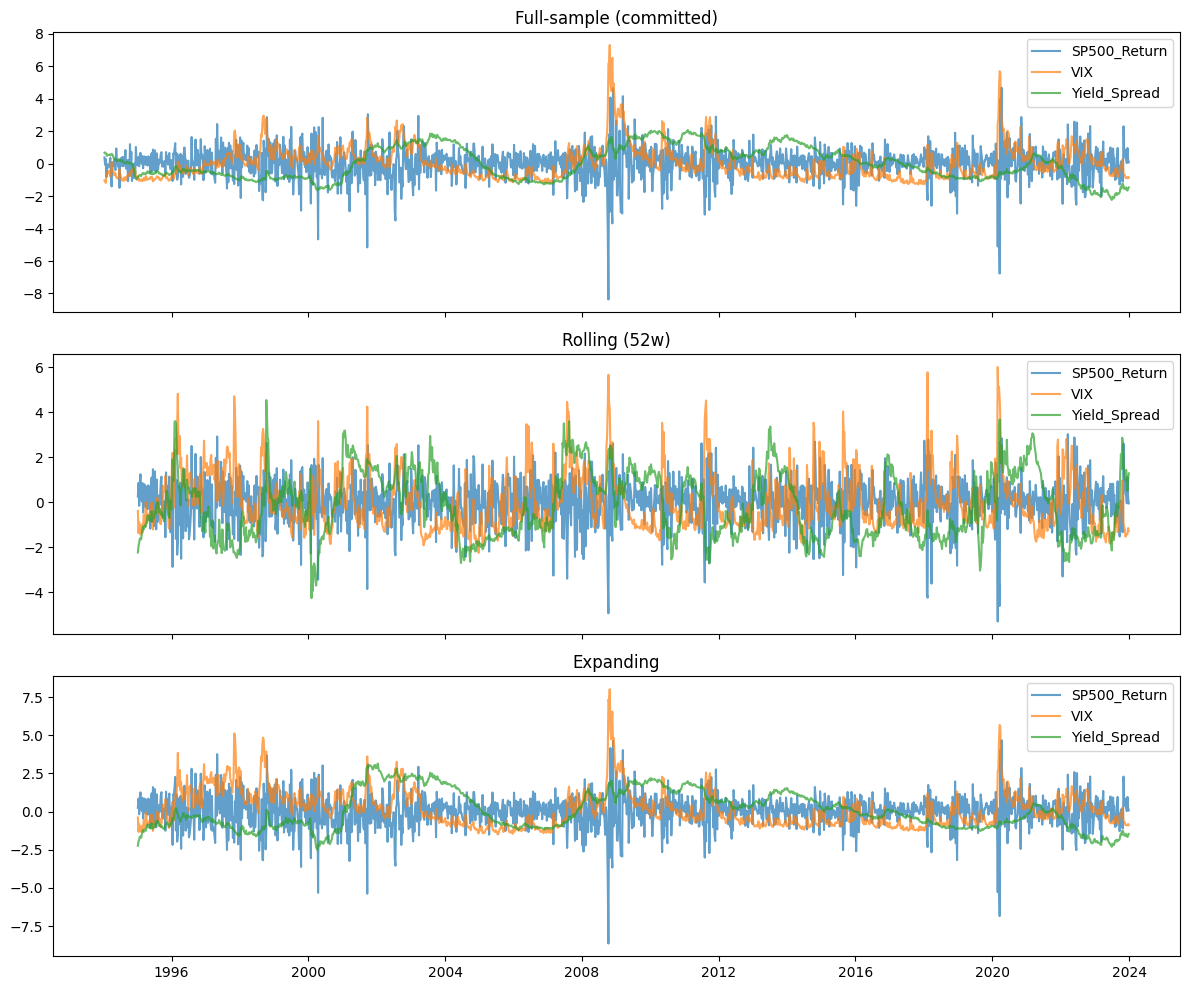

In [6]:

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, df, title in [
    (axes[0], full_std, "Full-sample (committed)"),
    (axes[1], rolling_std, "Rolling (52w)"),
    (axes[2], expanding_std, "Expanding"),
]:
    for col in MODEL_FEATURES:
        ax.plot(df.index, df[col], label=col, alpha=0.7)
    ax.set_title(title); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
